In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities, fit_kde_model
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd,
                            dens2lqd,
                            lqd2dens
                            )

In [71]:
mu = 0
sigma = 2
n = 256
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
grid = np.linspace(normal_sample.min(), normal_sample.max(), n)

params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
kde, density = fit_kde_model(normal_sample, params)

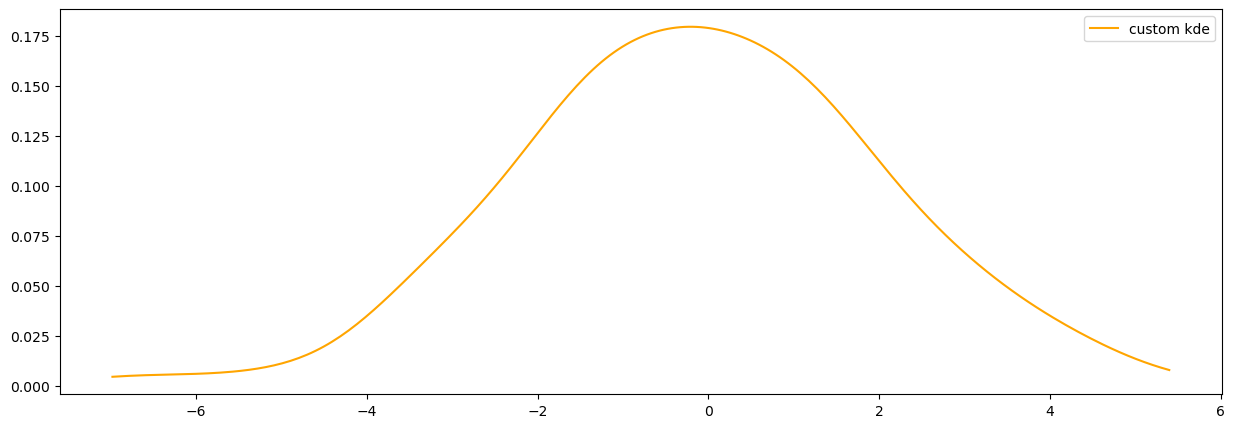

In [72]:
plt.figure(figsize=(15,5))

# sns.histplot(normal_sample, kde=True)
# sns.kdeplot(normal_sample, label="sns_kde")
sns.lineplot(x=kde.grid, y=density, color="orange", label="custom kde")

plt.show()

In [78]:
lqd_grid = np.linspace(0,1,3000)
t0_ = kde.grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


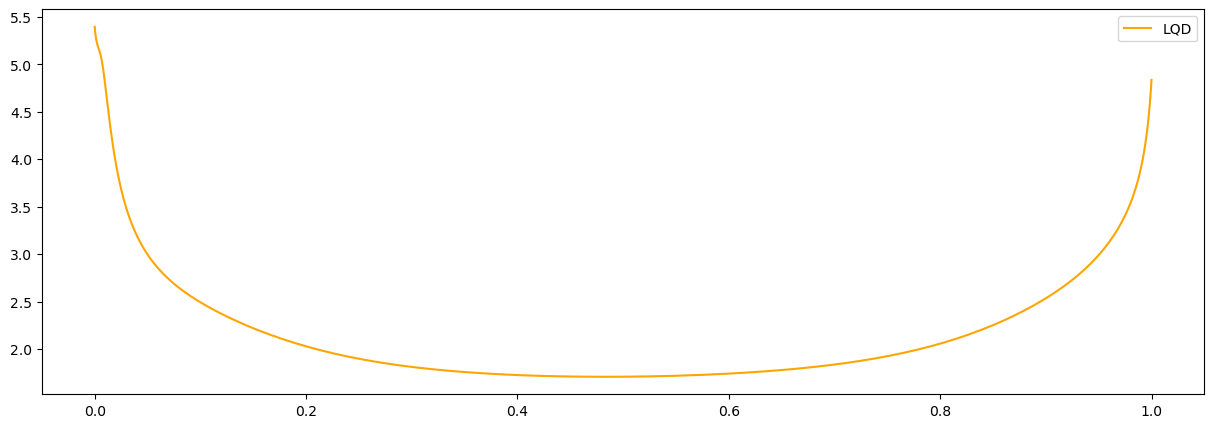

In [80]:
plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [81]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c)

c not in lqdSup — resetting to closest value.


/Users/vizzotto/Documents/GitHub/densities4risk/notebooks/../src/transformations.py:425: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  shift_v, _ = quad(fexp, lqdSup[0], lqdSup[c_ind])


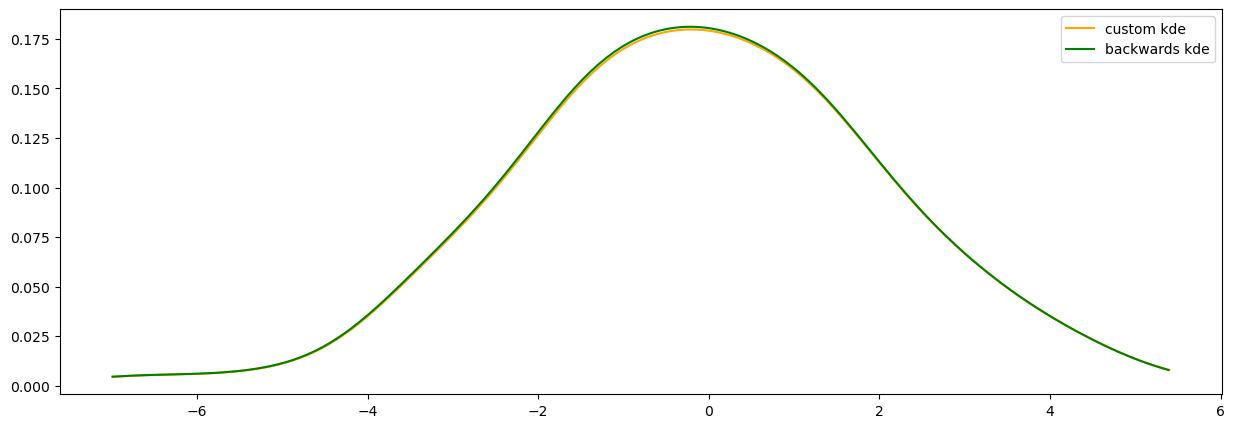

In [82]:
plt.figure(figsize=(15,5))

sns.lineplot(x=kde.grid, y=density, color="orange", label="custom kde")
sns.lineplot(x=dSup, y=dens, color="green", label="backwards kde")

plt.legend()

plt.show()